Introduction:

    This project analyzes over 6.3 million simulated banking transactions from the PaySim dataset using SQL, Python, and Tableau. The analysis focuses on understanding transaction behavior, identifying fraud patterns, monitoring high-value transactions, and evaluating operational risk indicators through exploratory data analysis, statistical summaries, and interactive dashboards.

Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("D:\DA Projects\Banking_Transaction_Monitoring_Analytics\data\PS_20174392719_1491204439457_log.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


Data Quality Assessment


In [3]:
df.shape

(6362620, 11)

In [4]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


Data Quality Assessment

Missing Values

In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate Rows

In [8]:
df.duplicated().sum()

np.int64(0)

Unique rows

In [9]:
df.nunique()

step                  743
type                    5
amount            5316900
nameOrig          6353307
oldbalanceOrg     1845844
newbalanceOrig    2682586
nameDest          2722362
oldbalanceDest    3614697
newbalanceDest    3555499
isFraud                 2
isFlaggedFraud          2
dtype: int64

Data types

In [10]:
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Data Profiling

Transaction Types

In [11]:
df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Fraud Distribution

In [12]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud Rate

In [13]:
round(df['isFraud'].mean()*100,3)

np.float64(0.129)

Fraud by Transaction Type

In [14]:
pd.crosstab(df['type'],df['isFraud'])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


Fraud Rate by Transaction Type

In [15]:
(df.groupby('type')['isFraud'].mean()*100).round(3)

type
CASH_IN     0.000
CASH_OUT    0.184
DEBIT       0.000
PAYMENT     0.000
TRANSFER    0.769
Name: isFraud, dtype: float64

Fraud Trend

In [16]:
fraud = df.groupby('step')['isFraud'].sum()

Transaction Type Analysis

In [17]:
df.groupby('type')['amount'].sum()

type
CASH_IN     2.363674e+11
CASH_OUT    3.944130e+11
DEBIT       2.271992e+08
PAYMENT     2.809337e+10
TRANSFER    4.852920e+11
Name: amount, dtype: float64

High Risk Transactions

Amount Summary

In [18]:
df['amount'].describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

Fraud Amount Summary

In [19]:
df.groupby('isFraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [20]:
df[df['amount'] > 200000]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
15,1,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.00,51513.44,0,0
19,1,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.00,0.00,0,0
24,1,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.00,2719172.89,0,0
82,1,TRANSFER,224606.64,C873175411,0.00,0.0,C766572210,354678.92,0.00,0,0
84,1,TRANSFER,379856.23,C1449772539,0.00,0.0,C1590550415,900180.00,19169204.93,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0


Fraud Loss Analysis

In [21]:
df[df['isFraud']==1]['amount'].sum()

np.float64(12056415427.84)

KPI Summary

In [22]:
kpi_summary = pd.DataFrame(
    {
        'Metric': [
            'Total Transactions', 
            'Total Transaction Value',
            'Fraud Transactions',
            'Fraud Rate %',
            'Average Transaction Amount'
        ],
        'Value': [
            len(df),
            round(df['amount'].sum(),2),
            int(df['isFraud'].sum()),
            round(df['isFraud'].mean()*100,3),
            round(df['amount'].mean(),2)
        ]
    }
)
kpi_summary

,Metric,Value
0,Total Transactions,6.362620e+06
1,Total Transaction Value,1.144393e+12
2,Fraud Transactions,8.213000e+03
3,Fraud Rate %,1.290000e-01
4,Average Transaction Amount,1.798619e+05


Transaction Summary

In [23]:
transaction_summary = (df.groupby('type').agg(
    transaction_count = ('type', 'count'),
    total_amount = ('amount', 'sum'),
    avg_amount = ('amount', 'mean')
).round(2)
)
transaction_summary.sort_values('total_amount' , ascending=False)
transaction_summary

,transaction_count,total_amount,avg_amount
type,,,
CASH_IN,1399284,2.363674e+11,168920.24
CASH_OUT,2237500,3.944130e+11,176273.96
DEBIT,41432,2.271992e+08,5483.67
PAYMENT,2151495,2.809337e+10,13057.60
TRANSFER,532909,4.852920e+11,910647.01


Fraud Summary

In [24]:
fraud_summary = (df.groupby('type').agg(
    transaction = ('type', 'count'),
    fraud_transactions = ('isFraud', 'sum')
)
)

fraud_summary['fraud_rate'] = (fraud_summary['fraud_transactions'] / fraud_summary['transaction'] * 100)

In [25]:
fraud_summary

,transaction,fraud_transactions,fraud_rate
type,,,
CASH_IN,1399284,0,0.000000
CASH_OUT,2237500,4116,0.183955
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000
TRANSFER,532909,4097,0.768799


In [26]:
treshhold = df['amount'].quantile(0.99)
print(treshhold)

1615979.4715999917


Transaction Type Distribution

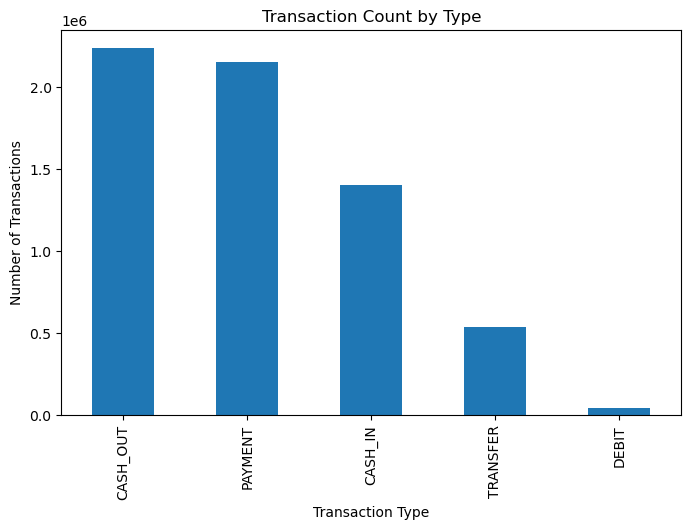

In [27]:
transaction_count = df['type'].value_counts()
plt.figure(figsize= (8,5))
transaction_count.plot(kind= 'bar')
plt.title('Transaction Count by Type')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.show()



Observation: Cash Out and Payment account for majority of the transactions.

Total Transaction Amount by Type

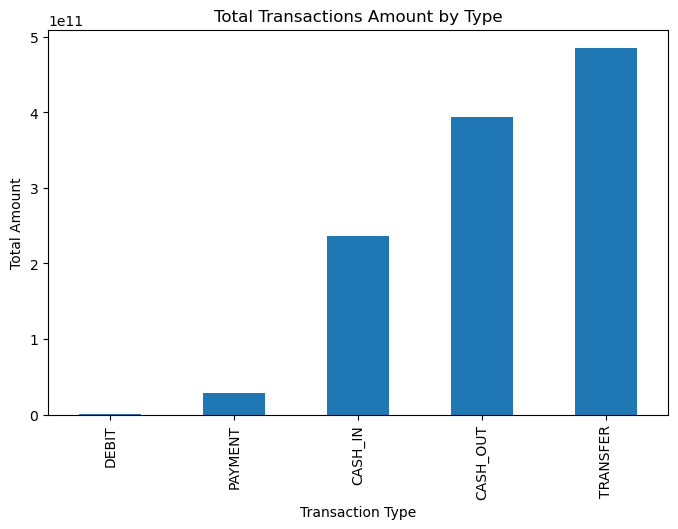

In [28]:
transaction_values = df.groupby('type')['amount'].sum().sort_values()

plt.figure(figsize=(8,5))
transaction_values.plot(kind='bar')
plt.title('Total Transactions Amount by Type')
plt.xlabel('Transaction Type')
plt.ylabel('Total Amount')
plt.show()

Observation: The Transfer and Cash Out account for highest transaction value despite their lower transaction count

Average Transaction Amount by Type

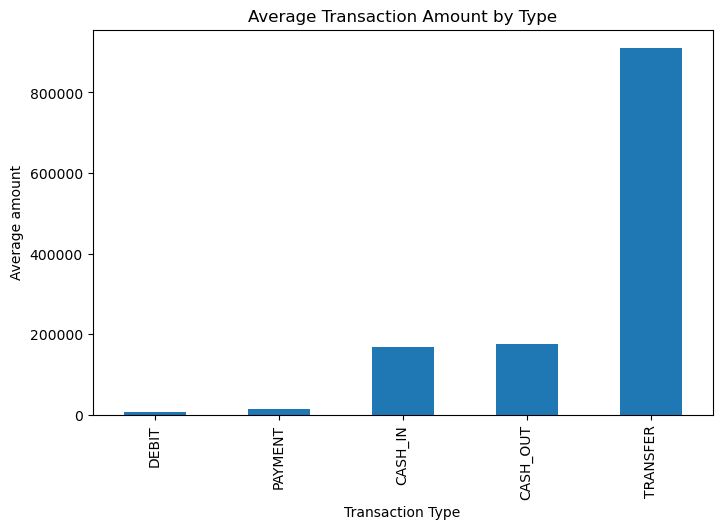

In [29]:
avg_amount = df.groupby('type')['amount'].mean().sort_values()

plt.figure(figsize=(8,5))
avg_amount.plot(kind= 'bar')
plt.title('Average Transaction Amount by Type')
plt.xlabel('Transaction Type')
plt.ylabel('Average amount')
plt.show()

Observation: The Transfer has the highest average transaction amount 

Fraud Count by Transaction Type

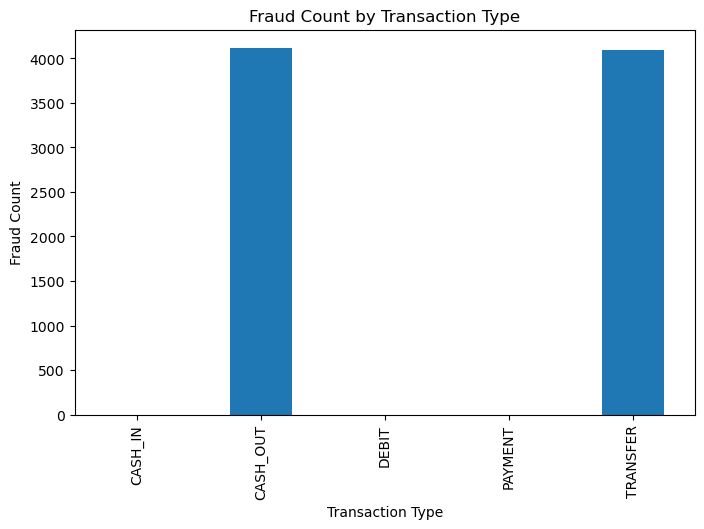

In [30]:
fraud_count = df.groupby('type')['isFraud'].sum()

plt.figure(figsize=(8,5))
fraud_count.plot(kind= 'bar')
plt.title('Fraud Count by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Count')
plt.show()

Observation: Fraud only occurs in Cash Out and Transfer transactions.

Fraud Rate by Transaction Type

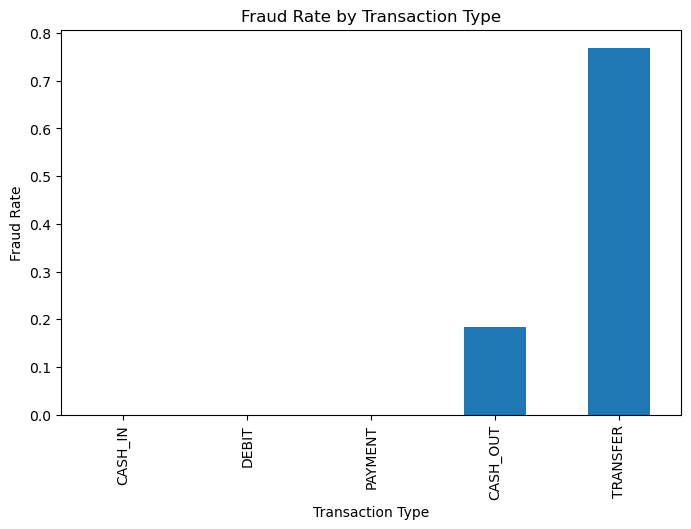

In [31]:
fraud_rate = (df.groupby('type')['isFraud'].mean().mul(100).sort_values())

plt.figure(figsize= (8,5))
fraud_rate.plot(kind='bar')
plt.title('Fraud Rate by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate')
plt.show()

Observation: The Transfers has the highest fraud rate.

Transaction Amount Distribution

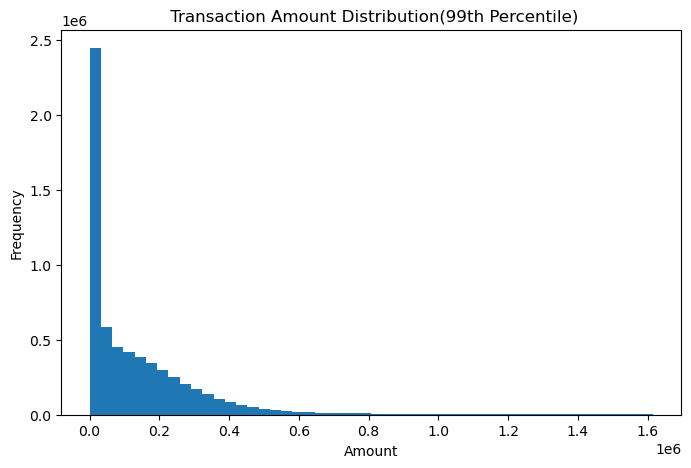

In [32]:
treshold = df['amount'].quantile(0.99)
plt.figure(figsize=(8,5))
plt.hist(df[df['amount']<= treshhold]['amount'], bins= 50)
plt.title(' Transaction Amount Distribution(99th Percentile)')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.show()

Observation: The majority of transactions fall within the lower amount transaction range indicating that the regular customer banking transactions consists of small value transactions.

Transaction Amount by Fraud Status

<Figure size 800x500 with 0 Axes>

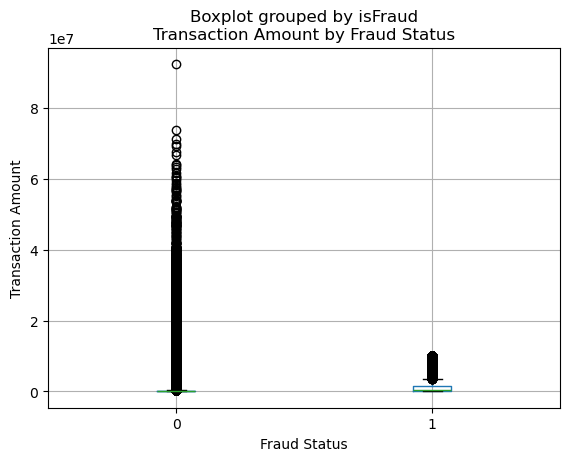

In [33]:
plt.figure(figsize=(8,5))
df.boxplot(column='amount', by= 'isFraud')

plt.title('Transaction Amount by Fraud Status')
plt.xlabel('Fraud Status')
plt.ylabel('Transaction Amount')
plt.show()

Observation: Fraudulant transactions have a higher median transactions tha the legitimate transactions.

Correlation Heatmap

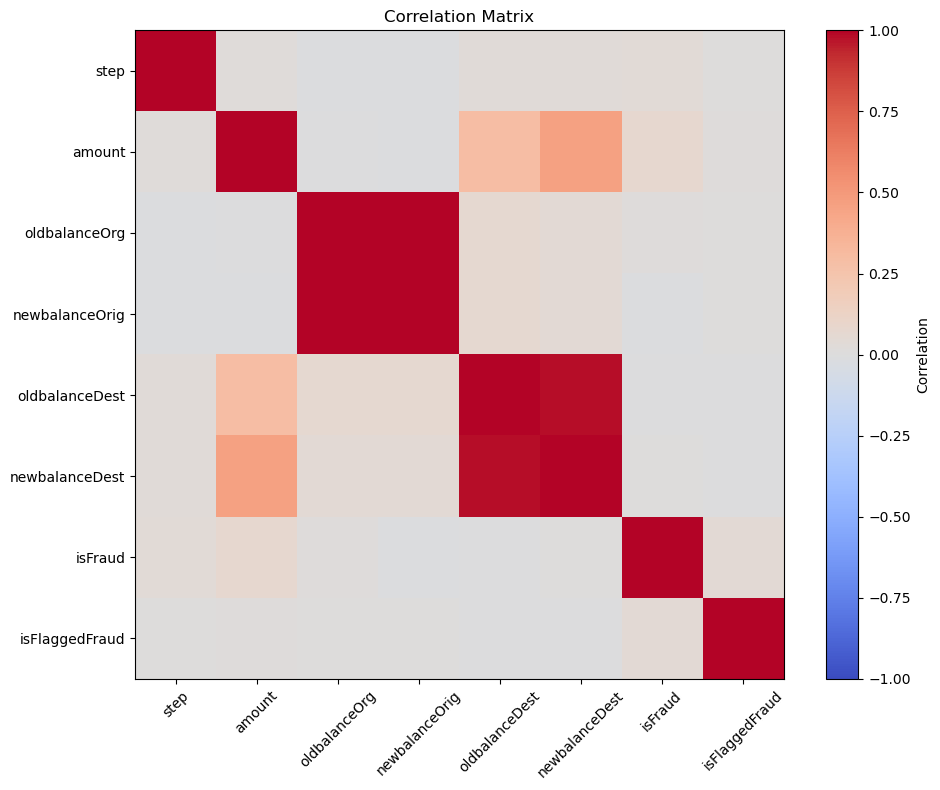

In [34]:
numeric_df = df.select_dtypes(include='number')

corr = numeric_df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap= 'coolwarm', vmin= -1, vmax=1)
plt.colorbar(label= 'Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation = 45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Observation: The oldbalanceOrg and newbalanceDest has strong correlation which indicates that expected balance deduction following the transaction.

Business Insights

1.  Customers transactions are dominated by low value payments
    Insight: The transaction amount distribution is highly right skewed. Most of the transactions lie in the low value while a low percentage has high value transactions.
    Business Impact: Relatively small number of high value transactions account for significant portion of financial exposure and operational risk.

2.  Transfer transactions carry the highest financial value
    Insight: Although Transfer transactions represent a smaller share of total transaction volume, the contribute the contribute the highest average transaction amount 
    Business Impact: Large value transactions require enhanced monitoring because they represent the great financial exposure.

3.  Fraud only occurs in Transfer and Cash Out transactions
    Insight: Fraud is completely concentrated in only two transactions types
    Business Impact: Fraud monitoring systems should prioritize Transfer and Cash Out transactions.

4.  Transfer has the highest fraud rate
    Insight: Transfer transactions are four times more likely to br fraudulent than Cash Out transactions
    Business Impact: Transfers should have highest risk score since it is highly succeptible of fraud risk.

5.  Fraudulent transactions involve significantly higher amounts
    Insight: While fraudulent transactions generally involve higher amounts, many legitimate transactions are also high-value. No single variable strongly predicts fraud.
    Business Impact: Fraud detection should combine multiple features such as transaction type, amount etc.

6.  Account balances exhibit expected financial relationships
    Insight: Account balances are internally consistent after transaction which indicates expected balance updates
    Business Impact: These can be used for reconciliation and anomaly detection by identifying transactions where expected balance changes do not occur.


Business Recommendations

1.  Prioritize monitoring of Transfer transactions.
2.  Implement enhanced fraud detection rules for Transfer transactions by applying stricter validation and real-time monitoring.
3.  Introduce risk-based monitoring for high-value transactions.
4.  Strengthen monitoring of Cash Out activity since Cash Out transactions account for a large proportion of fraudulent activity, implement additional controls.
5.  Build an executive fraud monitoring dashboard for realtime monitoring.

Project Conclusion:

    Analysis of over 6.3 million banking transactions identified clear operational and fraud patterns. Fraudulent activity was exclusively associated with Transfer and Cash Out transactions, with TRANSFER exhibiting the highest fraud rate.Fraudulent transactions involved substantially larger amounts than legitimate transactions. While transaction amount contributes to fraud risk, effective detection requires combining transaction type, account balance behavior.The findings support implementing a risk-based transaction monitoring framework that prioritizes high-value Transfer and Cash Out transactions to improve fraud detection efficiency while minimizing unnecessary reviews.